# Tucker / HOOI 基礎実装

このNotebookでは、HOSVDを初期値にして **HOOI (Higher-Order Orthogonal Iteration)** を自作する。

HOSVDは各modeのfactorを1回求めるのに対し、HOOIは他modeのfactorを使いながら各factorを反復更新する。

## このNotebookで自分で実装するもの

1. `mode 0` のfactorを1回更新する
2. `hooi_sweep()`：全modeを1回ずつ更新する
3. `core_from_factors()`：現在のfactorからcoreを計算する
4. `hooi()`：sweepを反復し、収束まで回す

それ以外の初期化・評価・可視化・TensorLyとの比較は用意してある。

## 完了条件

- HOOIの1 sweepを自分で書ける
- HOSVDとHOOIの違いを説明できる
- HOOIの誤差推移を確認できる
- 自作HOOIとTensorLyを再構成誤差で比較できる


## 1. 実験対象

3階テンソル `X` を、multilinear rank `(3, 2, 2)` で近似する。

ここではrank探索はしない。**同じrankでHOSVDとHOOIを比較すること**が目的。


In [2]:
import matplotlib.pyplot as plt
import torch

from nn_compression.compression import (
    hosvd,
    reconstruct_tucker,
    truncated_svd,
)
from nn_compression.metrics import relative_frobenius_error
from nn_compression.tensor import mode_dot, unfold

torch.manual_seed(0)

X = torch.randn(6, 5, 4)
ranks = {0: 3, 1: 2, 2: 2}

print("shape:", tuple(X.shape))
print("ranks:", ranks)


shape: (6, 5, 4)
ranks: {0: 3, 1: 2, 2: 2}


## 2. HOSVDを初期値にする

まず既存の `hosvd(X, ranks)` を実行し、HOOIを始める前のfactor・core・再構成誤差を保存する。

### 確認すること

- factorのshapeが各modeの元dimensionと指定rankに対応している
- この誤差がHOOI比較の基準値になる


In [3]:
core_hosvd, factors_hosvd = hosvd(X, ranks)
X_hat_hosvd = reconstruct_tucker(core_hosvd, factors_hosvd)
hosvd_error = relative_frobenius_error(X, X_hat_hosvd)

print("HOSVD core shape:", tuple(core_hosvd.shape))
for mode, U in factors_hosvd.items():
    print(f"mode={mode}: U.shape={tuple(U.shape)}")
print("HOSVD relative error:", float(hosvd_error))


HOSVD core shape: (3, 2, 2)
mode=0: U.shape=(6, 3)
mode=1: U.shape=(5, 2)
mode=2: U.shape=(4, 2)
HOSVD relative error: 0.8656705617904663


## 3. 練習1：mode 0 のfactorを1回更新する

HOOIの最小単位を、まずmode 0だけで実装する。

### やること

**入力**
- 元テンソル `X`
- 現在のfactor `factors_work`
- 更新対象 `mode = 0`
- 目標rank `ranks[0]`

**出力**
- 更新後の `U0` を `updated_u0` に入れる

### 条件

- 更新対象自身のfactorは、そのmodeの更新には使わない
- `mode_dot`、`unfold`、`truncated_svd` を使う
- 最終的に `updated_u0.shape == (X.shape[0], ranks[0])` になることを確認する

具体的な処理順はここでは示さない。HOOIの定義から組み立てる。


In [4]:
mode = 0
# 辞書内包表記
factors_work = {
    # cloneは別のメモリ上に保持する。
    # =は参照になるので、変わってしまう可能性がある。
    m: U.clone()
    for m, U in factors_hosvd.items()
}

projected = mode_dot(X,factors_work[1].T,1)
updated_u0,_,_ = truncated_svd(unfold(projected,0),ranks[0])

# 実装後に有効化
assert updated_u0.shape == (X.shape[0], ranks[0])
print("projected shape:", tuple(projected.shape))
print("updated U0 shape:", tuple(updated_u0.shape))


projected shape: (6, 2, 4)
updated U0 shape: (6, 3)


## 4. 練習2：`hooi_sweep()` を実装する

次に、mode 0だけの更新を全modeへ一般化する。

### やること

`hooi_sweep(X, factors, ranks)` を完成させ、**各modeのfactorを1回ずつ更新**する。

**入力**
- `X`: 元テンソル
- `factors`: 現在のfactor辞書
- `ranks`: modeごとの目標rank

**出力**
- 全mode更新後のfactor辞書

### 条件

- 更新は `ranks` に含まれる各modeについて行う
- sweep途中で更新済みのfactorがあれば、その最新値を使う
- 元の `factors` を直接書き換えない


In [5]:
def hooi_sweep(
    X: torch.Tensor,
    factors: dict[int, torch.Tensor],
    ranks: dict[int, int],
) -> dict[int, torch.Tensor]:
    
    updated_factors = {
        mode: U.clone()
        for mode, U in factors.items()
    }
    # --- mode 0: U0を更新 ---
    # X ×₁ U1^T
    projected_u1 = mode_dot(X,updated_factors[1].T,1)
    # unfold(..., 0) の左特異ベクトルからU0を得る
    updated_u0,_,_ = truncated_svd(unfold(projected_u1,0),ranks[0])            
    updated_factors[0] = updated_u0

    # --- mode 1: U1を更新 ---
    # X ×₀ U0^T
    projected_u0 = mode_dot(X,updated_u0.T,0)
    # unfold(..., 1) の左特異ベクトルからU1を得る
    updated_u1,_,_ = truncated_svd(unfold(projected_u0,1),ranks[1])
    updated_factors[1] = updated_u1
    
    return updated_factors



## 5. 練習3：`core_from_factors()` を実装する

factorを更新しただけではTucker分解は完成しない。現在のfactorに対応するcoreを元の `X` から計算する。

### やること

`core_from_factors(X, factors)` を完成させる。

**入力**
- `X`: 元テンソル
- `factors`: 現在のfactor辞書

**出力**
- Tucker core

### 確認すること

この設定では最終的なcore shapeが `(3, 2, 2)` になる。


In [6]:
def core_from_factors(
    X: torch.Tensor,
    factors: dict[int, torch.Tensor],
) -> torch.Tensor:
    core = X

    for mode, U in factors.items():
        core = mode_dot(core, U.T, mode)
    return core

## 6. 練習4：`hooi()` を実装する

最後に、HOSVD初期化からHOOIの反復までを1つの関数にまとめる。

### やること

`hooi(X, ranks, max_iter, tol)` を完成させる。

**処理の大枠**
- HOSVDで初期化する
- `hooi_sweep()` を反復する
- 各sweep後にcoreと再構成誤差を計算する
- 誤差の変化が十分小さくなったら停止する

**返り値**
- 最終core
- 最終factor辞書
- HOSVD初期値を含むrelative Frobenius errorの履歴 `history`

ここではループ内部の具体的なコードは示さない。


In [7]:
def reconstruction_errors_norm(
    X: torch.Tensor,
    X_hat: torch.Tensor,
    eps: float = 1e-12,
) -> tuple[torch.Tensor, torch.Tensor]:
    absolute_error = torch.linalg.vector_norm(X - X_hat)
    relative_error = absolute_error / torch.linalg.vector_norm(X).clamp_min(eps)

    return absolute_error, relative_error

In [8]:
def has_converged(
    error: float,
    prev_error: float,
    *,
    abs_tol: float = 1e-8,
    rel_tol: float = 1e-5,
) -> bool:
    absolute_change = abs(error - prev_error)

    return absolute_change <= abs_tol + rel_tol * abs(prev_error)

In [11]:
def hooi(
    X: torch.Tensor,
    ranks: dict[int, int],
    max_iter: int = 30,
    tol: float = 1e-6,
) -> tuple[
    torch.Tensor,
    dict[int, torch.Tensor],
    list[float],
]:
    core_hosvd, factors_hosvd = hosvd(X, ranks)
    X_hat_hosvd = reconstruct_tucker(core_hosvd, factors_hosvd)
    error = float(relative_frobenius_error(X, X_hat_hosvd))
    history = [error]
    prev_error = error

    updated_factors = factors_hosvd
    for epoch in range(max_iter):
        updated_factors = hooi_sweep(X, updated_factors, ranks)
        core = core_from_factors(X, updated_factors)
        X_hat_hosvd = reconstruct_tucker(core, updated_factors)
        error = float(relative_frobenius_error(X, X_hat_hosvd))
        history.append(error)
        jadge = has_converged(error, prev_error)
        prev_error = error
        if jadge == True:
            break
    return core, updated_factors, history
    

## 7. HOSVDと自作HOOIを比較する

ここからは評価用。上の3関数を実装したら実行する。

### 確認すること

- `history[0]` がHOSVDの誤差になっている
- sweep後の誤差がどのように変化するか
- 最終HOOI誤差がHOSVDと比べてどうなったか
- factorそのものではなく、**再構成結果と誤差**を比較する


In [12]:
core_hooi, factors_hooi, history = hooi(
    X,
    ranks,
    max_iter=30,
    tol=1e-7,
)

X_hat_hooi = reconstruct_tucker(core_hooi, factors_hooi)
hooi_error = relative_frobenius_error(X, X_hat_hooi)

print("HOSVD error:", float(hosvd_error))
print("HOOI  error:", float(hooi_error))
print("iterations:", len(history) - 1)
print("history:", history)

assert len(history) >= 1
assert abs(history[0] - float(hosvd_error)) < 1e-6
assert tuple(core_hooi.shape) == tuple(ranks[mode] for mode in range(X.ndim))


HOSVD error: 0.8656705617904663
HOOI  error: 0.8219621181488037
iterations: 8
history: [0.8656705617904663, 0.8303212523460388, 0.8241822719573975, 0.8226500749588013, 0.8221779465675354, 0.8220292329788208, 0.8219820261001587, 0.8219669461250305, 0.8219621181488037]


## 8. 誤差の推移を可視化する

HOOIが反復法であることを、sweepごとのrelative Frobenius errorから確認する。


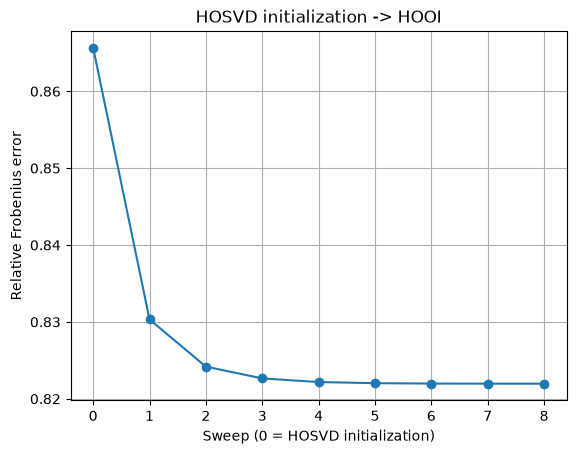

In [13]:
plt.plot(range(len(history)), history, marker="o")
plt.xlabel("Sweep (0 = HOSVD initialization)")
plt.ylabel("Relative Frobenius error")
plt.title("HOSVD initialization -> HOOI")
plt.grid(True)
plt.show()


## 9. TensorLyと比較する

最後に、自作実装が大きくずれていないかをTensorLyで検証する。

TensorLyは**答えを作るためではなく検証用**として使う。

### 比較するもの

- core / factorのshape
- 再構成tensorのshape
- relative Frobenius error

factorの数値そのものは、符号や基底の取り方が異なるため完全一致を要求しない。


In [14]:
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor

tl.set_backend("pytorch")

rank_list = [ranks[mode] for mode in range(X.ndim)]

core_tl, factors_tl = tucker(
    X,
    rank=rank_list,
    init="svd",
    n_iter_max=100,
    tol=1e-8,
)

X_hat_tl = tucker_to_tensor((core_tl, factors_tl))
tensorly_error = relative_frobenius_error(X, X_hat_tl)

print("self HOSVD:", float(hosvd_error))
print("self HOOI :", float(hooi_error))
print("TensorLy  :", float(tensorly_error))

print("TensorLy core:", tuple(core_tl.shape))
for mode, U in enumerate(factors_tl):
    print(f"TensorLy mode={mode}: U.shape={tuple(U.shape)}")


self HOSVD: 0.8656705617904663
self HOOI : 0.8219621181488037
TensorLy  : 0.7685527205467224
TensorLy core: (3, 2, 2)
TensorLy mode=0: U.shape=(6, 3)
TensorLy mode=1: U.shape=(5, 2)
TensorLy mode=2: U.shape=(4, 2)


## 10. 最後に整理する

実装と比較が終わったら、自分の言葉で次を説明する。

1. HOSVDとHOOIではfactorの求め方がどう違うか
2. HOOIで1つのfactorを更新するとき、なぜ他modeのfactorを使うのか
3. 1 sweepとは何か
4. なぜHOOIはHOSVDより計算量が増えるのか
5. 同じmultilinear rankでもHOOIを使う意味は何か

ここまで説明できれば、このNotebookは完了。
